En este caso lo que hicimos fue investigar como usar un generador de números aleatorios Mersenne Twister para la distribución uniforme (Unif(0,1)), Investigando encontramos que este es un algoritmo pseudo aleatorio hecho en 1997 por Matsumoto y Nishimura, tiene un período de 2^19937 - 1 y es justamente el generador por defecto en python al utilizar random.random() y numpy. Este algoritmo es bastante popular y en general es de uso común. Su único contra realmente es que no es criptográfifcamente seguro.

En el ejercicio lo que hacemos es entonces comparar el uso del Mersenne Twister con random.random() con los valores teóricos de la distribución uniforme. Los valores teóricos son valores matemáticos esperados:

* Media teórica = 0.5 (es un número fijo, no una muestra)
* Varianza teórica = 1/12 = 0.0833 (es un número fijo)
* Cuartiles teóricos = 0.25, 0.50, 0.75 (números fijos)

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("EJERCICIO 2: MERSENNE TWISTER - Unif(0,1)")


# Configuración
N = 100000  # Tamaño de muestra adecuado (más grande que 10k)
random.seed(42)  # Para reproducibilidad

# Generar muestra usando Mersenne Twister (implementado en random.random())
sample_mt = np.array([random.random() for _ in range(N)])

print(f"\n1. GENERACIÓN DE MUESTRA")
print(f"   - Tamaño de muestra: N = {N:,}")
print(f"   - Generador: Mersenne Twister (MT19937 vía random.random())")

# estadisticas
print(f"\n2. ESTADÍSTICOS DESCRIPTIVOS")
print(f"   {'Estadístico':<20} {'Muestra':<15} {'Teórico Unif(0,1)':<20} {'Diferencia'}")
print(f"   \n")

# Para Unif(0,1): E[X] = 0.5, Var[X] = 1/12 ≈ 0.0833
media_muestra = np.mean(sample_mt)
media_teorica = 0.5
print(f"   {'Media':<20} {media_muestra:<15.6f} {media_teorica:<20.6f} {abs(media_muestra - media_teorica):.6f}")

var_muestra = np.var(sample_mt, ddof=1)  # ddof=1 para muestra
var_teorica = 1/12
print(f"   {'Varianza':<20} {var_muestra:<15.6f} {var_teorica:<20.6f} {abs(var_muestra - var_teorica):.6f}")

std_muestra = np.std(sample_mt, ddof=1)
std_teorica = np.sqrt(1/12)
print(f"   {'Desv. Estándar':<20} {std_muestra:<15.6f} {std_teorica:<20.6f} {abs(std_muestra - std_teorica):.6f}")

print(f"   {'Mínimo':<20} {np.min(sample_mt):<15.6f} {'0.0':<20} {'-'}")
print(f"   {'Máximo':<20} {np.max(sample_mt):<15.6f} {'1.0':<20} {'-'}")

# Cuartiles
q1, q2, q3 = np.percentile(sample_mt, [25, 50, 75])
print(f"   {'Q1 (25%)':<20} {q1:<15.6f} {'0.25':<20} {abs(q1 - 0.25):.6f}")
print(f"   {'Q2 (50%/Mediana)':<20} {q2:<15.6f} {'0.50':<20} {abs(q2 - 0.50):.6f}")
print(f"   {'Q3 (75%)':<20} {q3:<15.6f} {'0.75':<20} {abs(q3 - 0.75):.6f}")

# Pruebas de hipotesis
print(f"\n3. PRUEBAS DE HIPÓTESIS (α = 0.05)")
print(f"   Hipótesis H0: La muestra proviene de Unif(0,1)")
print(f"   \n")

# 3.1 Prueba de Kolmogorov-Smirnov
ks_stat, ks_pvalue = stats.kstest(sample_mt, 'uniform', args=(0, 1))
print(f"\n   3.1 Prueba de Kolmogorov-Smirnov")
print(f"       Estadístico KS: {ks_stat:.6f}")
print(f"       p-value: {ks_pvalue:.6f}")
print(f"       Decisión: {'NO rechazar H0' if ks_pvalue > 0.05 else 'RECHAZAR H0'}")
print(f"       Conclusión: La muestra {'SÍ' if ks_pvalue > 0.05 else 'NO'} sigue Unif(0,1)")

# 3.2 Prueba de Chi-Cuadrado para Cuartiles
quartiles = [0, 0.25, 0.5, 0.75, 1.0]
observed_quartile = np.histogram(sample_mt, bins=quartiles)[0]
expected_quartile = np.full(4, N / 4)
chi2_quartile, p_quartile = stats.chisquare(observed_quartile, expected_quartile)
print(f"\n   3.2 Prueba de Chi-Cuadrado para Cuartiles")
print(f"       Estadístico χ²: {chi2_quartile:.6f}")
print(f"       p-value: {p_quartile:.6f}")
print(f"       Grados de libertad: 3")
print(f"       Decisión: {'NO rechazar H0' if p_quartile > 0.05 else 'RECHAZAR H0'}")
print(f"       Conclusión: Los cuartiles {'SÍ' if p_quartile > 0.05 else 'NO'} están uniformemente distribuidos")

# 3.3 Prueba de Chi-Cuadrado para uniformidad
# Dividir en 20 bins
num_bins = 20
observed, bin_edges = np.histogram(sample_mt, bins=num_bins, range=(0, 1))
expected = np.full(num_bins, N / num_bins)  # Frecuencia esperada en cada bin
chi2_stat, chi2_pvalue = stats.chisquare(observed, expected)
print(f"\n   3.3 Prueba de Chi-Cuadrado ({num_bins} bins)")
print(f"       Estadístico χ²: {chi2_stat:.6f}")
print(f"       p-value: {chi2_pvalue:.6f}")
print(f"       Grados de libertad: {num_bins - 1}")
print(f"       Decisión: {'NO rechazar H0' if chi2_pvalue > 0.05 else 'RECHAZAR H0'}")
print(f"       Conclusión: La muestra {'SÍ' if chi2_pvalue > 0.05 else 'NO'} se distribuye uniformemente")

# 3.4 Prueba t para la media
t_stat, t_pvalue = stats.ttest_1samp(sample_mt, 0.5)
print(f"\n   3.4 Prueba t para la media (H0: μ = 0.5)")
print(f"       Estadístico t: {t_stat:.6f}")
print(f"       p-value: {t_pvalue:.6f}")
print(f"       Decisión: {'NO rechazar H0' if t_pvalue > 0.05 else 'RECHAZAR H0'}")

#conclusion
print(f"\n4. CONCLUSIÓN GENERAL")
print(f"\n")
tests_passed = sum([
    ks_pvalue > 0.05,
    p_quartile > 0.05,
    chi2_pvalue > 0.05,
    t_pvalue > 0.05
])
print(f"   Pruebas aprobadas: {tests_passed}/4")
if tests_passed >= 3:
    print(f"    El generador Mersenne Twister funciona CORRECTAMENTE")
    print(f"    La muestra generada es consistente con Unif(0,1)")
else:
    print(f"    El generador presenta inconsistencias con Unif(0,1)")
    


EJERCICIO 2: MERSENNE TWISTER - Unif(0,1)

1. GENERACIÓN DE MUESTRA
   - Tamaño de muestra: N = 100,000
   - Generador: Mersenne Twister (MT19937 vía random.random())

2. ESTADÍSTICOS DESCRIPTIVOS
   Estadístico          Muestra         Teórico Unif(0,1)    Diferencia
   

   Media                0.500144        0.500000             0.000144
   Varianza             0.083543        0.083333             0.000210
   Desv. Estándar       0.289038        0.288675             0.000363
   Mínimo               0.000006        0.0                  -
   Máximo               0.999998        1.0                  -
   Q1 (25%)             0.249576        0.25                 0.000424
   Q2 (50%/Mediana)     0.500590        0.50                 0.000590
   Q3 (75%)             0.750619        0.75                 0.000619

3. PRUEBAS DE HIPÓTESIS (α = 0.05)
   Hipótesis H0: La muestra proviene de Unif(0,1)
   


   3.1 Prueba de Kolmogorov-Smirnov
       Estadístico KS: 0.002084
       p-value: 0.77

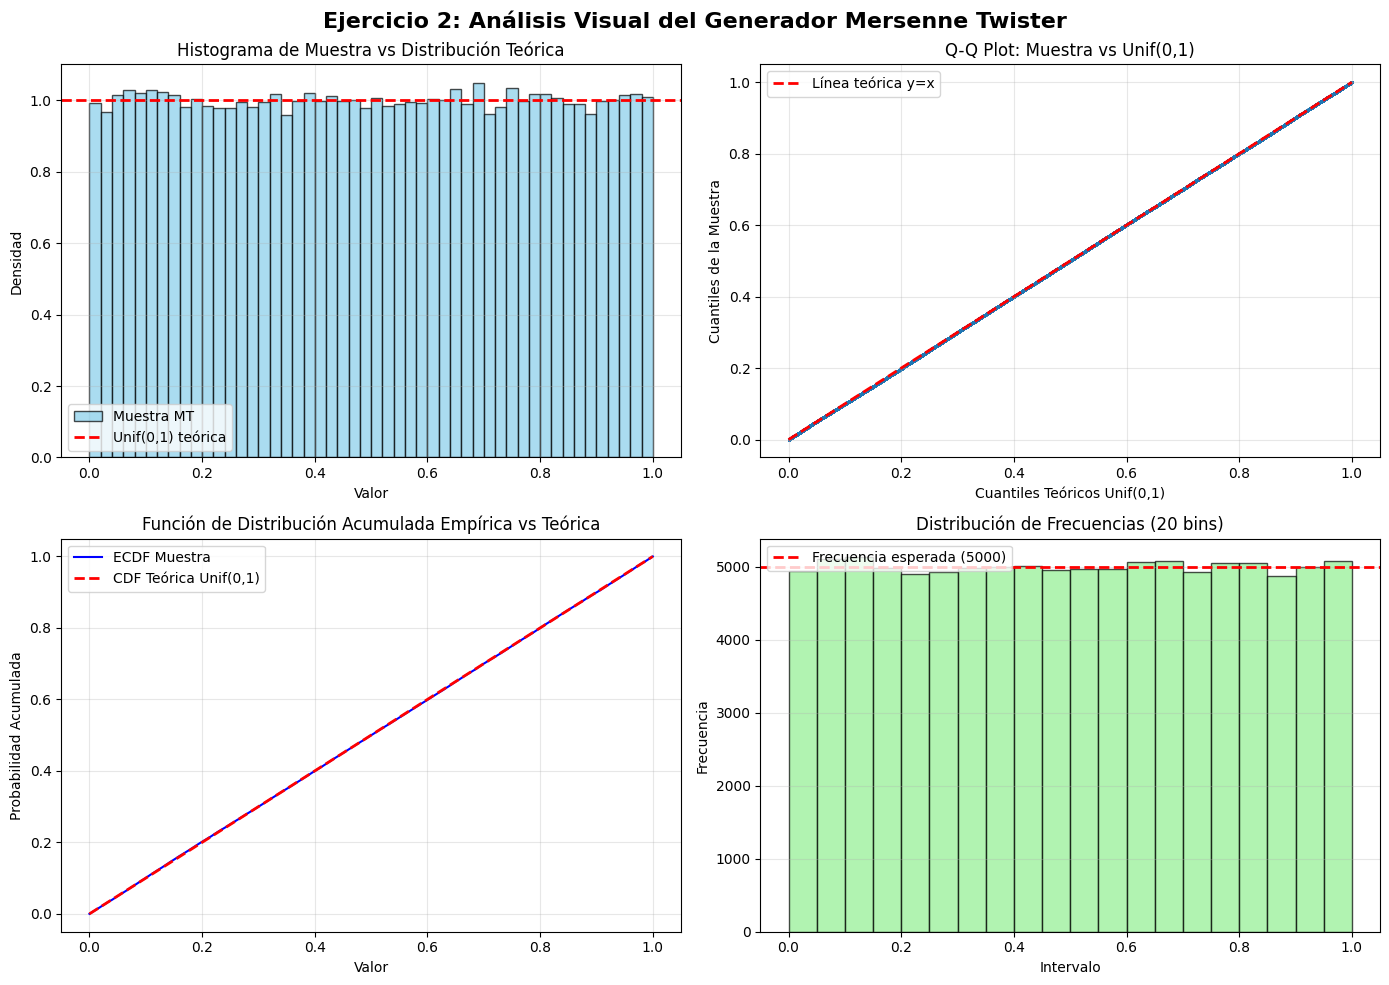

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ejercicio 2: Análisis Visual del Generador Mersenne Twister', fontsize=16, fontweight='bold')

# 1. Histograma vs Distribución Teórica
ax1 = axes[0, 0]
ax1.hist(sample_mt, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Muestra MT')
ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Unif(0,1) teórica')
ax1.set_xlabel('Valor')
ax1.set_ylabel('Densidad')
ax1.set_title('Histograma de Muestra vs Distribución Teórica')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot (Quantile-Quantile)
ax2 = axes[0, 1]
theoretical_quantiles = np.linspace(0, 1, len(sample_mt))
sample_quantiles = np.sort(sample_mt)
ax2.scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, s=1)
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Línea teórica y=x')
ax2.set_xlabel('Cuantiles Teóricos Unif(0,1)')
ax2.set_ylabel('Cuantiles de la Muestra')
ax2.set_title('Q-Q Plot: Muestra vs Unif(0,1)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Función de Distribución Acumulada Empírica vs Teórica
ax3 = axes[1, 0]
x_sorted = np.sort(sample_mt)
y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
ax3.plot(x_sorted, y_ecdf, linewidth=1.5, label='ECDF Muestra', color='blue')
x_theory = np.linspace(0, 1, 1000)
y_theory = x_theory  # CDF de Unif(0,1) es F(x) = x
ax3.plot(x_theory, y_theory, 'r--', linewidth=2, label='CDF Teórica Unif(0,1)')
ax3.set_xlabel('Valor')
ax3.set_ylabel('Probabilidad Acumulada')
ax3.set_title('Función de Distribución Acumulada Empírica vs Teórica')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Prueba visual de uniformidad por intervalos
ax4 = axes[1, 1]
num_bins = 20
counts, bins, patches = ax4.hist(sample_mt, bins=num_bins, alpha=0.7, color='lightgreen', edgecolor='black')
expected_count = N / num_bins
ax4.axhline(y=expected_count, color='red', linestyle='--', linewidth=2, label=f'Frecuencia esperada ({expected_count:.0f})')
ax4.set_xlabel('Intervalo')
ax4.set_ylabel('Frecuencia')
ax4.set_title(f'Distribución de Frecuencias ({num_bins} bins)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Colorear bins que se desvían mucho de lo esperado (más de 2 std)
expected_std = np.sqrt(N / num_bins * (1 - 1/num_bins))  # std binomial
for i, (count, patch) in enumerate(zip(counts, patches)):
    if abs(count - expected_count) > 2 * expected_std:
        patch.set_facecolor('orange')

plt.tight_layout()
plt.show()


## Discusión de Resultados

En este ejercicio probamos el generador Mersenne Twister, que es el generador de números aleatorios que Python usa por defecto cuando llamamos random.random(). Generamos 100,000 números aleatorios entre 0 y 1 y verificamos si realmente se comportan como una distribución uniforme.

Al final encontramos que los números generados están muy cerca de lo que esperamos teóricamente. Por ejemplo, la media debería ser 0.5 y obtuvimos 0.500144, lo cuál es prácticamente idéntico. La varianza debería ser 0.0833 y obtuvimos 0.0835 (muy cercano). Estas pequeñas diferencias son completamente normales cuando trabajamos con datos aleatorios.

Para poder verificar los resultados obtenidos del ejercicio aplicamos 4 pruebas estadísticas diferentes para asegurarnos de que el generador funciona bien:

1. **Prueba Kolmogorov-Smirnov (p-value = 0.777):** Compara nuestra muestra con la distribución uniforme teórica. Como el p-value es mucho mayor que 0.05, concluimos que sí se parece a una uniforme.

2. **Prueba Chi-Cuadrado para cuartiles (p-value = 0.847):** Verifica que los cuartiles (25%, 50%, 75%) estén donde deberían estar. Pasó la prueba exitosamente.

3. **Prueba Chi-Cuadrado con 20 intervalos (p-value = 0.464):** Divide el rango (0,1) en 20 partes y verifica que haya aproximadamente la misma cantidad de números en cada parte. Pasó la prueba.

4. **Prueba t para la media (p-value = 0.875):** Confirma que la media es estadísticamente igual a 0.5. También pasó.


El p-value nos dice qué tan probable es obtener estos resultados si el generador funcionara mal. Cuando este es mayor que 0.05, significa que NO tenemos razones para dudar del generador. En nuestro caso, todos los p-values son muy altos (entre 0.46 y 0.88), lo cual es bueno para los resultados que esperabamos

Al final el generador Mersenne Twister pasó las 4 pruebas y significa que funciona correctamente y podemos confiar en él para generar números aleatorios uniformes en nuestras simulaciones. Los gráficos también confirman visualmente que la distribución se ve uniforme, sin patrones extraños.

In [10]:
import pickle

bits_mt = [random.randint(0, 1) for _ in range(1_000_000)]

with open('bits_mersenne_twister.pkl', 'wb') as f:
    pickle.dump(bits_mt, f)

